Завдання 1: Обрати унікальний датасет з https://archive.ics.uci.edu/datasets , який відповідає наступним вимогам:
a.	Dataset Characteristics: Multivariate
b.	Attribute Characteristics: Categorical, Integer, Real
c.	Number of Attributes: at least 2 integers/real
d.	Has Missing Values: Yes

Обрав датасет Auto MPG (https://archive.ics.uci.edu/dataset/9/auto+mpg). Самостійно встановив датасет.

Завдання 2. Здійснити Data Cleaning

In [1]:
import pandas as pd

file_path = "auto-mpg.data" 
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(file_path, names=column_names, sep=r'\s+', na_values='?')

print(" Кількість пропущених значень до очищення ")
print(df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()

print("\n Дані після очищення ")
print(df.info())

display(df.head())

 Кількість пропущених значень до очищення 
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

 Дані після очищення 
<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car_name      392 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 30.6 KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


Завдання 3: Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc)
Я обрав scatter plot, де витрата пального залежить від ваги автомобіля, з кольоровим виділенням за кількістю циліндрів.
А також зробив lineplot, де показав залежність прискорення автомобіля від року його випуску

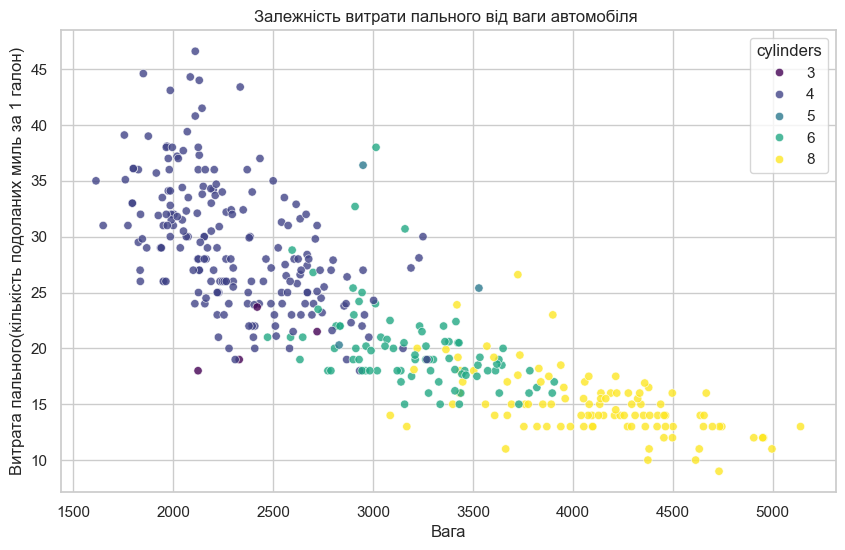

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='viridis', alpha=0.8)

plt.title('Залежність витрати пального від ваги автомобіля ')
plt.xlabel('Вага')
plt.ylabel('Витрата пального(кількість подоланих миль за 1 галон)')

plt.show()

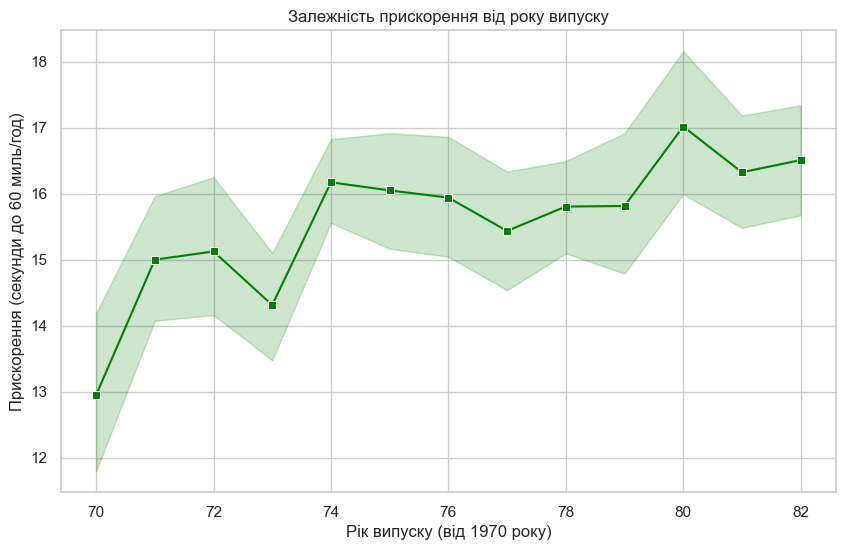

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='model_year', y='acceleration', marker='s', color='green')

plt.title('Залежність прискорення від року випуску')
plt.xlabel('Рік випуску (від 1970 року)')
plt.ylabel('Прискорення (секунди до 60 миль/год)')

plt.show()

Завдання 4: Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

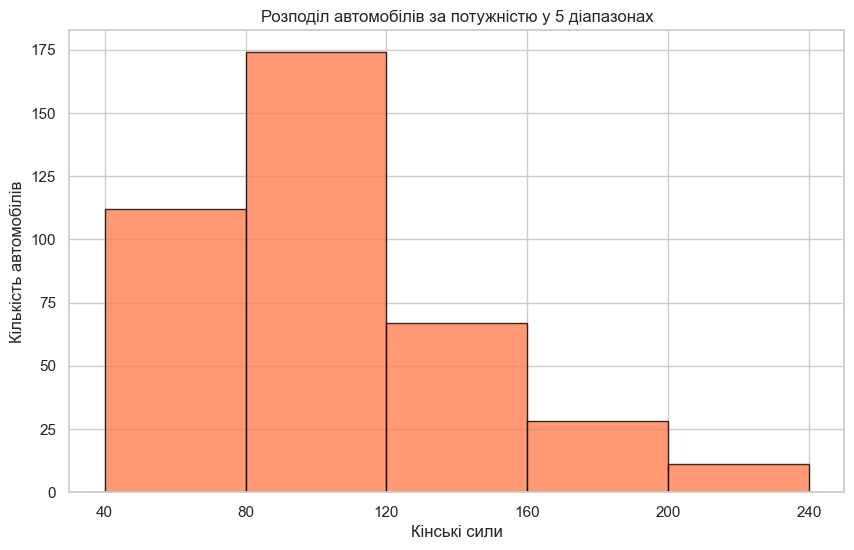

In [29]:
import matplotlib.pyplot as plt

bins = [40, 80, 120, 160, 200, 240] 
plt.figure(figsize=(10, 6))
plt.hist(df['horsepower'], bins=bins, color='coral', edgecolor='black', alpha=0.8)

plt.title('Розподіл автомобілів за потужністю у 5 діапазонах')
plt.xlabel('Кінські сили')
plt.ylabel('Кількість автомобілів')

plt.xticks(bins)

plt.show()

Завдання 5: Збудувати графіки, використовуючи приклади.
Графік 1, графік, який показує загальну тенденцію характеристик автомобілів у різних регіонах.
Графік 2, по графіку, видно, що чи більше циліндрів, тим більше кінських сил, вага та споживання пального на милю, а також протилежна ситуація для меншої кількості циліндрів.
Графік 3, з плином часу, покращується еффективність споживання палива машинами
Графік 4, Японія має найкращу еффктивність витрачання палива, в той час, як США має низькі медіанні показники. Європейський регіон має велику кількість машин з статистичними викидами.

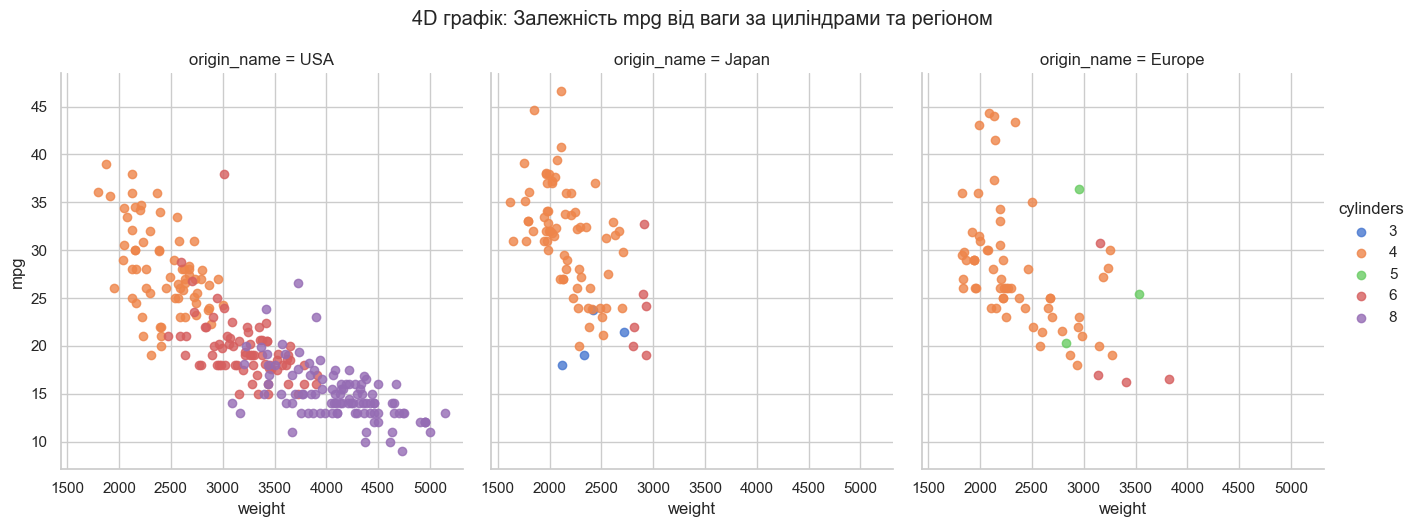

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df['origin_name'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

g = sns.lmplot(
    data=df, 
    x="weight", 
    y="mpg", 
    hue="cylinders", 
    col="origin_name", 
    palette="muted",
    height=5, 
    aspect=0.9,
    fit_reg=False )

g.fig.suptitle('4D графік: Залежність mpg від ваги за циліндрами та регіоном', y=1.05)

plt.show()

df = df.drop(columns=['origin_name'])

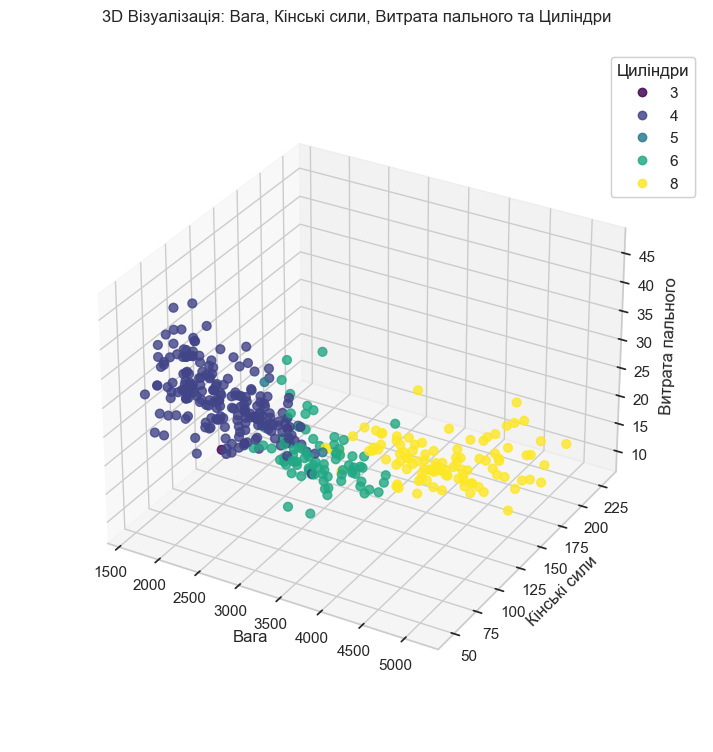

In [16]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

x = df['weight']
y = df['horsepower']
z = df['mpg']
c = df['cylinders']

scatter = ax.scatter(x, y, z, c=c, cmap='viridis', s=40, alpha=0.8)

legend = ax.legend(*scatter.legend_elements(), title="Циліндри")
ax.add_artist(legend)

ax.set_xlabel('Вага')
ax.set_ylabel('Кінські сили')
ax.set_zlabel('Витрата пального') 
ax.set_title('3D Візуалізація: Вага, Кінські сили, Витрата пального та Циліндри', pad=20)
ax.set_box_aspect(None, zoom=0.85)

plt.show()

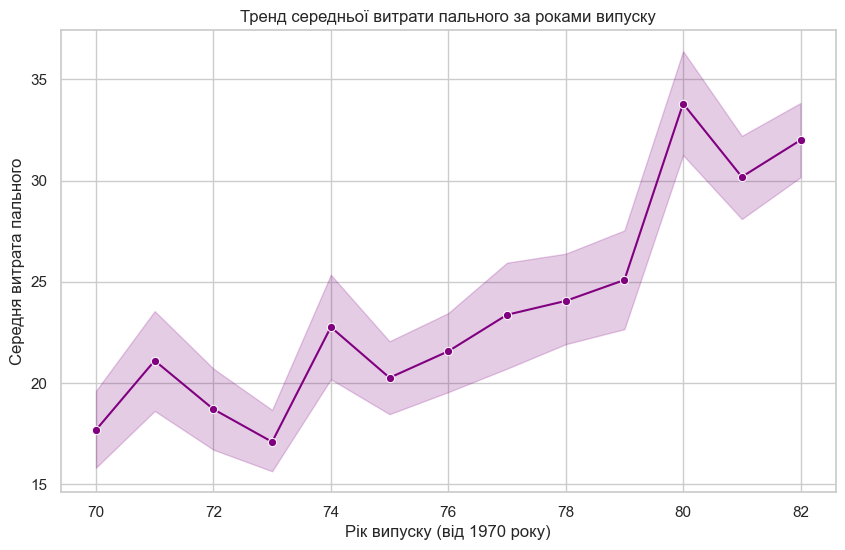

In [24]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='model_year', y='mpg', marker='o', color='purple')
plt.title('Тренд середньої витрати пального за роками випуску')
plt.xlabel('Рік випуску (від 1970 року)')
plt.ylabel('Середня витрата пального')
plt.show()

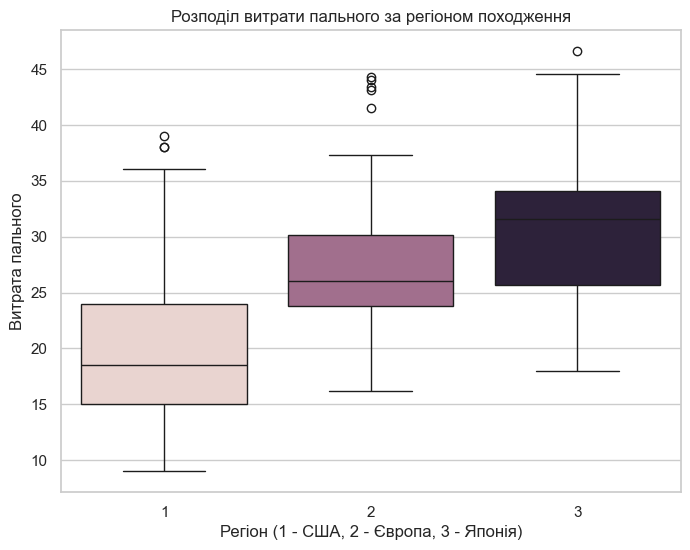

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='origin', y='mpg', hue='origin', legend=False)
plt.title('Розподіл витрати пального за регіоном походження')
plt.xlabel('Регіон (1 - США, 2 - Європа, 3 - Японія)')
plt.ylabel('Витрата пального')
plt.show()